[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github.com/MLinApp-polito/mla-prj-23-project-am04_group-am01/blob/main/defect_detection.ipynb)

TODO: fix the button

# PBF Defect Detection

This notebook covers data loading, training, validation, and inference for detecting defects in Powder Bed Fusion images using a fine-tuned CNN.

## Clone GithHub repo

In [ ]:
!rm -rf mla_project/

In [1]:
import os

if not os.path.exists("/content/mla-prj-23-project-am04_group-am01") and not os.path.exists("/content/mla_project"):
  # DON'T SHARE THE PERSONAL ACCESS TOKEN

  # change the name of the branch here as needed
  !git clone -b gan https://***REMOVED-GITHUB-TOKEN***@github.com/MLinApp-polito/mla-prj-23-project-am04_group-am01.git

  # Rename folder for simplicity
  !mv /content/mla-prj-23-project-am04_group-am01 /content/mla_project

!cd /content/mla_project && git pull

Cloning into 'mla-prj-23-project-am04_group-am01'...
remote: Enumerating objects: 1677, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 1677 (delta 64), reused 66 (delta 36), pack-reused 1575 (from 2)
Receiving objects: 100% (1677/1677), 1.58 GiB | 30.81 MiB/s, done.
Resolving deltas: 100% (866/866), done.
Updating files: 100% (317/317), done.
Already up to date.


## Install Dependencies

In [2]:
!pip install torch torchvision matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 95.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

## Imports

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## Dataset mean and std

In [ ]:
!python /content/mla_project/src/data_loader.py --data-dir /content/mla_project/images/original --compute-stats

Dataset mean (grayscale): 0.5839
Dataset std (grayscale): 0.2074


## Training - no augmentation

### Define paths and parameters

In [ ]:
data_dir = '/content/mla_project/images/original'

# Training params
batch_size = 2
epochs = 10
learning_rate = 1e-5
backbone = 'resnet50'
device = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


### Launch training

In [ ]:
# Execute train script directly

!python /content/mla_project/src/train.py \
    --data-dir "{data_dir}" \
    --batch-size {batch_size} \
    --epochs {epochs} \
    --lr {learning_rate} \
    --backbone {backbone} \
    --num-workers 2 \
    --k-folds 5

Training with K-Fold cross-validation
Using device: cuda

===== Fold 1 =====

[Fold 1] Number of training images: 64
[Fold 1] Number of validation images: 16
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
[Fold 1] Epoch 1/10 | Train Loss: 0.6500, Acc: 0.6719 | Val Loss: 0.6849, Acc: 0.5625, Precision: 0.3164, Recall: 0.5625, F1: 0.4050
[Fold 1] Epoch 2/10 | Train Loss: 0.4624, Acc: 0.8281 | Val Loss: 0.2510, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
[Fold 1] Epoch 3/10 | Train Loss: 0.5009, Acc: 0.8125 | Val Loss: 0.1242, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
[Fold 1] Epoch 4/10 | Train Loss: 0.3219

### Plot Training & Validation Curves

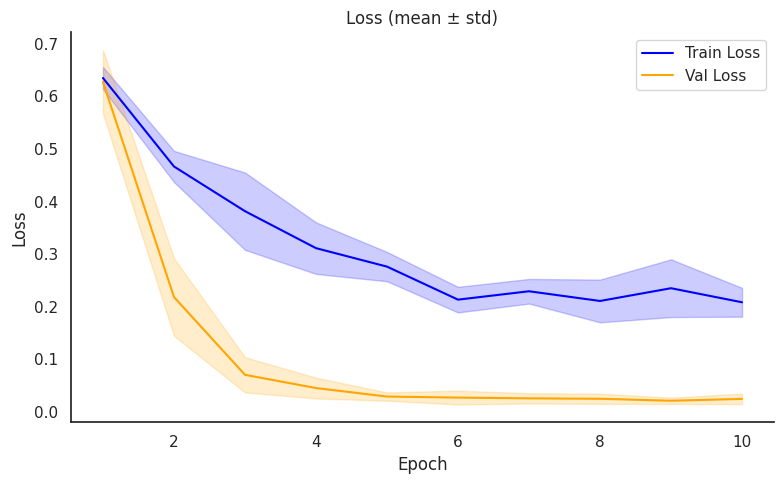

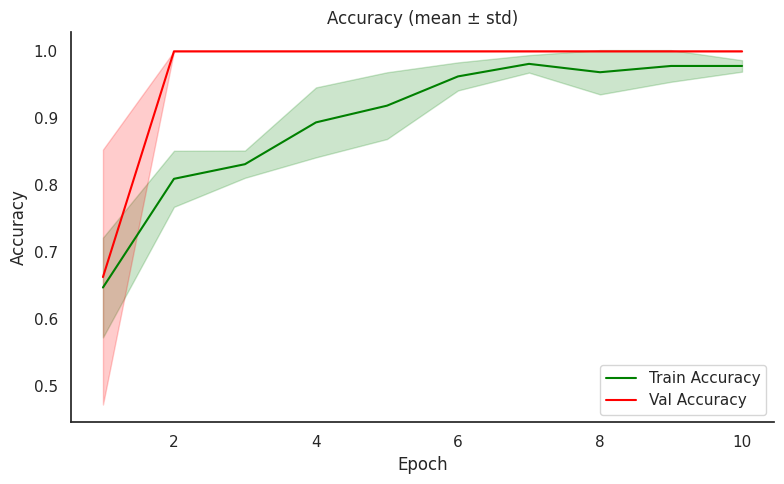

In [ ]:
# plot for cross-validation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read logs
logs = pd.read_csv('/content/kfold_logs.csv')

# Group for epoch and get mean and std
grouped = logs.groupby('epoch').agg({
    'train_loss': ['mean', 'std'],
    'val_loss': ['mean', 'std'],
    'train_acc': ['mean', 'std'],
    'val_acc': ['mean', 'std']
}).reset_index()

# Rename columns
grouped.columns = ['epoch',
                   'train_loss_mean', 'train_loss_std',
                   'val_loss_mean', 'val_loss_std',
                   'train_acc_mean', 'train_acc_std',
                   'val_acc_mean', 'val_acc_std']

# Set style
sns.set(style="white", context="notebook")

# LOSS
plt.figure(figsize=(8, 5))
plt.plot(grouped['epoch'], grouped['train_loss_mean'], label='Train Loss', color='blue')
plt.fill_between(grouped['epoch'],
                 grouped['train_loss_mean'] - grouped['train_loss_std'],
                 grouped['train_loss_mean'] + grouped['train_loss_std'],
                 color='blue', alpha=0.2)

plt.plot(grouped['epoch'], grouped['val_loss_mean'], label='Val Loss', color='orange')
plt.fill_between(grouped['epoch'],
                 grouped['val_loss_mean'] - grouped['val_loss_std'],
                 grouped['val_loss_mean'] + grouped['val_loss_std'],
                 color='orange', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss (mean ± std)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

# ACCURACY
plt.figure(figsize=(8, 5))
plt.plot(grouped['epoch'], grouped['train_acc_mean'], label='Train Accuracy', color='green')
plt.fill_between(grouped['epoch'],
                 grouped['train_acc_mean'] - grouped['train_acc_std'],
                 grouped['train_acc_mean'] + grouped['train_acc_std'],
                 color='green', alpha=0.2)

plt.plot(grouped['epoch'], grouped['val_acc_mean'], label='Val Accuracy', color='red')
plt.fill_between(grouped['epoch'],
                 grouped['val_acc_mean'] - grouped['val_acc_std'],
                 grouped['val_acc_mean'] + grouped['val_acc_std'],
                 color='red', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy (mean ± std)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()


## Training - basic augmentations (simple transformations)

In [ ]:
data_dir = '/content/mla_project/images/original'

# Training params
batch_size = 2
epochs = 10
learning_rate = 1e-5
backbone = 'resnet50'
device = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [ ]:
!python /content/mla_project/src/train.py \
    --data-dir "{data_dir}" \
    --batch-size {batch_size} \
    --epochs {epochs} \
    --lr {learning_rate} \
    --backbone {backbone} \
    --num-workers 2 \
    --k-folds 5 \
    --aug "True"

Training with K-Fold cross-validation
Using device: cuda

===== Fold 1 =====

[Fold 1] Number of training images: 64
[Fold 1] Number of validation images: 16
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
[Fold 1] Epoch 1/10 | Train Loss: 0.6208, Acc: 0.7500 | Val Loss: 0.8070, Acc: 0.5625, Precision: 0.3164, Recall: 0.5625, F1: 0.4050
[Fold 1] Epoch 2/10 | Train Loss: 0.4720, Acc: 0.7656 | Val Loss: 0.3316, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
[Fold 1] Epoch 3/10 | Train Loss: 0.4057, Acc: 0.7969 | Val Loss: 0.0782, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
[Fold 1] Epoch 4/10 | Train Loss: 0.3538

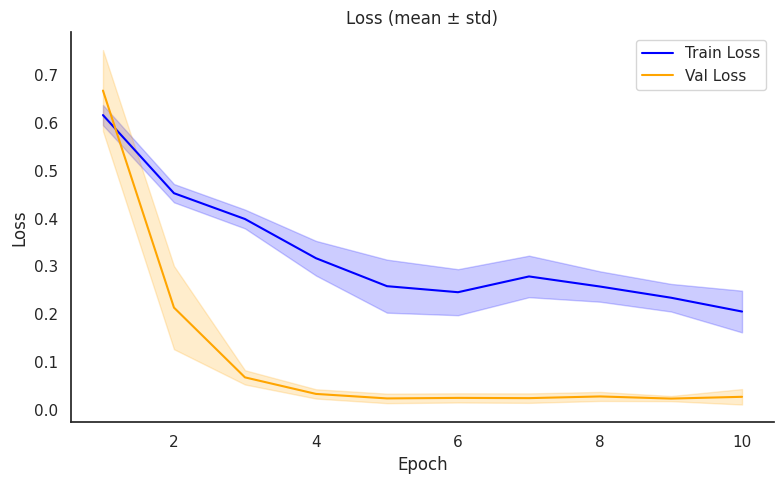

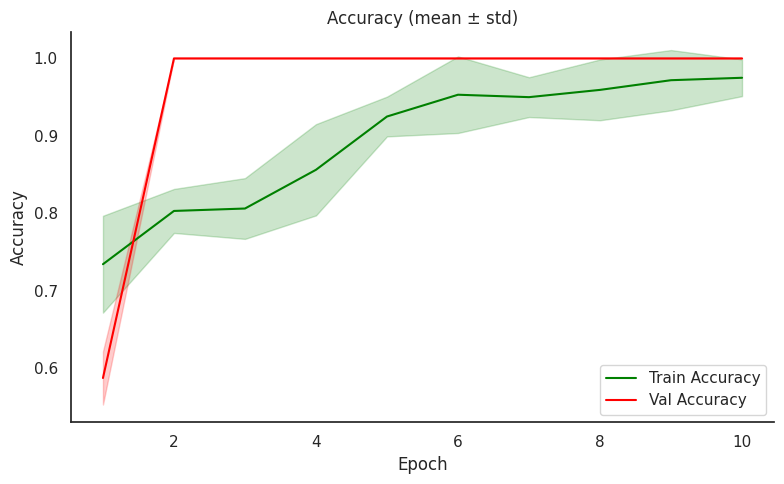

In [ ]:
# plot for cross-validation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read logs
logs = pd.read_csv('/content/kfold_logs.csv')

# Group for epoch and get mean and std
grouped = logs.groupby('epoch').agg({
    'train_loss': ['mean', 'std'],
    'val_loss': ['mean', 'std'],
    'train_acc': ['mean', 'std'],
    'val_acc': ['mean', 'std']
}).reset_index()

# Rename columns
grouped.columns = ['epoch',
                   'train_loss_mean', 'train_loss_std',
                   'val_loss_mean', 'val_loss_std',
                   'train_acc_mean', 'train_acc_std',
                   'val_acc_mean', 'val_acc_std']

# Set style
sns.set(style="white", context="notebook")

# LOSS
plt.figure(figsize=(8, 5))
plt.plot(grouped['epoch'], grouped['train_loss_mean'], label='Train Loss', color='blue')
plt.fill_between(grouped['epoch'],
                 grouped['train_loss_mean'] - grouped['train_loss_std'],
                 grouped['train_loss_mean'] + grouped['train_loss_std'],
                 color='blue', alpha=0.2)

plt.plot(grouped['epoch'], grouped['val_loss_mean'], label='Val Loss', color='orange')
plt.fill_between(grouped['epoch'],
                 grouped['val_loss_mean'] - grouped['val_loss_std'],
                 grouped['val_loss_mean'] + grouped['val_loss_std'],
                 color='orange', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss (mean ± std)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

# ACCURACY
plt.figure(figsize=(8, 5))
plt.plot(grouped['epoch'], grouped['train_acc_mean'], label='Train Accuracy', color='green')
plt.fill_between(grouped['epoch'],
                 grouped['train_acc_mean'] - grouped['train_acc_std'],
                 grouped['train_acc_mean'] + grouped['train_acc_std'],
                 color='green', alpha=0.2)

plt.plot(grouped['epoch'], grouped['val_acc_mean'], label='Val Accuracy', color='red')
plt.fill_between(grouped['epoch'],
                 grouped['val_acc_mean'] - grouped['val_acc_std'],
                 grouped['val_acc_mean'] + grouped['val_acc_std'],
                 color='red', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy (mean ± std)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

## Training - VAEs

### Install requirements

In [ ]:
# install requirements
#!cd /content/mla_project/external/VAEs && pip install -r requirements.txt
!pip install pip==23.3.1
!pip install pytorch-lightning
!pip install --upgrade pip
!pip install PyYAML==6.0 torch torchvision tensorboard torchsummary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.1/823.1 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 10.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 23.3.1
    Uninstalling pip-23.3.1:
      Successfully uninstalled pip-23.3.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 757.9/757.9 kB 23.7 MB/s eta 0:00:00
  Attempting uninstall: PyYAML
    Found existing installation: PyYAML 6.0.2
    Uninstalling PyYAML-6.0.2:
      Successfully uninstalled PyYAML-6.0.2


### Train a Vanilla VAE

Note: the yaml file is vae_defect.yaml

In [ ]:
!python /content/mla_project/external/PyTorch-VAE/run.py -c /content/mla_project/external/PyTorch-VAE/configs/vae_defects.yaml

Seed set to 42
Setting up datasets for stage: None
Total images loaded: 74
Total images loaded: 74
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
======= Training VanillaVAE =======
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/1
----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 1 processes
----------------------------------------------------------------------------------------------------

2025-04-28 18:02:57.828401: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745863377.849695    2282 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:174586

### Train a Conditional VAE

In [ ]:
!python /content/mla_project/external/PyTorch-VAE/run.py -c /content/mla_project/external/PyTorch-VAE/configs/cvae_defects.yaml

Seed set to 42
Setting up datasets for stage: None
data_dir:  /content/mla_project/images/original
Total images loaded: 74
data_dir:  /content/mla_project/images/original
Total images loaded: 74
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
======= Training ConditionalVAE =======
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/1
----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 1 processes
----------------------------------------------------------------------------------------------------

2025-04-29 14:54:07.540807: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745938447.560498   58226 cuda_dnn.cc:8310] Unable to register cuDNN factory: Att

### Generate new images using Vanilla VAE

Note: change the path to the checkpoint if it's saved in another place

In [ ]:
!python /content/mla_project/external/PyTorch-VAE/generate.py --checkpoint /content/mla_project/models/augmentation/VAEs/vanilla_vae.ckpt \
                                                              --config /content/mla_project/external/PyTorch-VAE/configs/vae_defects.yaml \
                                                              --data-dir /content/mla_project/images/original \
                                                              --output-folder /content/generated_images \
                                                              --device cuda

Total images loaded: 74
Generated image saved to /content/generated_images/generated_0.png
Generated image saved to /content/generated_images/generated_1.png
Generated image saved to /content/generated_images/generated_2.png
Generated image saved to /content/generated_images/generated_3.png
Generated image saved to /content/generated_images/generated_4.png
Generated image saved to /content/generated_images/generated_5.png
Generated image saved to /content/generated_images/generated_6.png
Generated image saved to /content/generated_images/generated_7.png
Generated image saved to /content/generated_images/generated_8.png
Generated image saved to /content/generated_images/generated_9.png
Generated image saved to /content/generated_images/generated_10.png
Generated image saved to /content/generated_images/generated_11.png
Generated image saved to /content/generated_images/generated_12.png
Generated image saved to /content/generated_images/generated_13.png
Generated image saved to /content/

In [ ]:
!zip -r /content/generated_images.zip /content/generated_images


  adding: content/generated_images/ (stored 0%)
  adding: content/generated_images/generated_1.png (deflated 0%)
  adding: content/generated_images/generated_14.png (deflated 0%)
  adding: content/generated_images/generated_0.png (deflated 0%)
  adding: content/generated_images/generated_13.png (deflated 0%)
  adding: content/generated_images/generated_8.png (stored 0%)
  adding: content/generated_images/generated_5.png (deflated 0%)
  adding: content/generated_images/generated_6.png (deflated 0%)
  adding: content/generated_images/generated_4.png (deflated 0%)
  adding: content/generated_images/generated_9.png (stored 0%)
  adding: content/generated_images/generated_10.png (stored 0%)
  adding: content/generated_images/generated_12.png (deflated 0%)
  adding: content/generated_images/generated_11.png (stored 0%)
  adding: content/generated_images/generated_7.png (stored 0%)
  adding: content/generated_images/generated_3.png (deflated 0%)
  adding: content/generated_images/generated_2.

### Gnerate new images using conditional VAE

In [ ]:
!python /content/mla_project/external/PyTorch-VAE/generate.py --checkpoint /content/mla_project/models/augmentation/VAEs/cvae.ckpt \
                                                              --config /content/mla_project/external/PyTorch-VAE/configs/cvae_defects.yaml \
                                                              --data-dir /content/mla_project/images/original \
                                                              --output-folder /content/generated_images_cvae \
                                                              --model "cvae" \
                                                              --device cuda

data_dir:  /content/mla_project/images/original
Total images loaded: 74
Generated sample saved to /content/generated_images_cvae/class_0/sample_0.png
Generated sample saved to /content/generated_images_cvae/class_0/sample_1.png
Generated sample saved to /content/generated_images_cvae/class_0/sample_2.png
Generated sample saved to /content/generated_images_cvae/class_0/sample_3.png
Generated sample saved to /content/generated_images_cvae/class_0/sample_4.png
Generated sample saved to /content/generated_images_cvae/class_0/sample_5.png
Generated sample saved to /content/generated_images_cvae/class_0/sample_6.png
Generated sample saved to /content/generated_images_cvae/class_0/sample_7.png
Generated sample saved to /content/generated_images_cvae/class_0/sample_8.png
Generated sample saved to /content/generated_images_cvae/class_0/sample_9.png
Generated sample saved to /content/generated_images_cvae/class_0/sample_10.png
Generated sample saved to /content/generated_images_cvae/class_0/samp

In [ ]:
# prompt: zip generate folder

!zip -r /content/generated_images_cvae.zip /content/generated_images_cvae


  adding: content/generated_images_cvae/ (stored 0%)
  adding: content/generated_images_cvae/class_1/ (stored 0%)
  adding: content/generated_images_cvae/class_1/sample_27.png (stored 0%)
  adding: content/generated_images_cvae/class_1/sample_18.png (stored 0%)
  adding: content/generated_images_cvae/class_1/sample_12.png (stored 0%)
  adding: content/generated_images_cvae/class_1/sample_7.png (stored 0%)
  adding: content/generated_images_cvae/class_1/sample_15.png (stored 0%)
  adding: content/generated_images_cvae/class_1/sample_17.png (stored 0%)
  adding: content/generated_images_cvae/class_1/sample_10.png (stored 0%)
  adding: content/generated_images_cvae/class_1/sample_28.png (stored 0%)
  adding: content/generated_images_cvae/class_1/sample_2.png (deflated 0%)
  adding: content/generated_images_cvae/class_1/sample_11.png (stored 0%)
  adding: content/generated_images_cvae/class_1/sample_19.png (stored 0%)
  adding: content/generated_images_cvae/class_1/sample_16.png (stored 0%

## Training - GANs

In [4]:
!python /content/mla_project/external/PyTorch-GAN/implementations/dcgan/dcgan.py \
    --generate_defect \
    --data_dir "/content/mla_project/images/original/Defects" \
    --batch_size 4 \
    --n_epochs 1500 \
    --img_size 512 \
    --sample_interval 400

Output streaming troncato alle ultime 5000 righe.
[Epoch 1084/1500] [Batch 1/12] [D loss: 0.678618] [G loss: 3.875501]
[Epoch 1084/1500] [Batch 2/12] [D loss: 0.091579] [G loss: 1.530665]
[Epoch 1084/1500] [Batch 3/12] [D loss: 0.559708] [G loss: 0.358744]
[Epoch 1084/1500] [Batch 4/12] [D loss: 0.537338] [G loss: 0.999593]
[Epoch 1084/1500] [Batch 5/12] [D loss: 0.081035] [G loss: 7.428495]
[Epoch 1084/1500] [Batch 6/12] [D loss: 0.198841] [G loss: 8.765078]
[Epoch 1084/1500] [Batch 7/12] [D loss: 1.165342] [G loss: 6.582686]
[Epoch 1084/1500] [Batch 8/12] [D loss: 0.061137] [G loss: 4.257468]
[Epoch 1084/1500] [Batch 9/12] [D loss: 0.332128] [G loss: 1.953610]
[Epoch 1084/1500] [Batch 10/12] [D loss: 0.118218] [G loss: 2.285591]
[Epoch 1084/1500] [Batch 11/12] [D loss: 0.095649] [G loss: 1.239426]
[Epoch 1085/1500] [Batch 0/12] [D loss: 0.400129] [G loss: 3.318548]
[Epoch 1085/1500] [Batch 1/12] [D loss: 0.029672] [G loss: 3.246066]
[Epoch 1085/1500] [Batch 2/12] [D loss: 0.603518] [

### Generate new images using GANs

In [5]:
!python /content/mla_project/external/PyTorch-GAN/implementations/dcgan/generate.py \
      --model_path "/content/saved_models/generator_epoch_1499.pth" \
      --img_size 512 \
      --num_images 10 \
      --output_dir "/content/generated_images"

Generated 10 images in /content/generated_images


In [7]:
!zip -r /content/generated_images_1500.zip /content/generated_images

  adding: content/generated_images/ (stored 0%)
  adding: content/generated_images/image_6.png (deflated 0%)
  adding: content/generated_images/image_9.png (deflated 0%)
  adding: content/generated_images/image_4.png (deflated 0%)
  adding: content/generated_images/image_2.png (deflated 0%)
  adding: content/generated_images/image_0.png (deflated 0%)
  adding: content/generated_images/image_5.png (deflated 0%)
  adding: content/generated_images/image_7.png (deflated 0%)
  adding: content/generated_images/image_8.png (deflated 0%)
  adding: content/generated_images/image_3.png (deflated 0%)
  adding: content/generated_images/image_1.png (deflated 0%)
